# Task
Predict movie ratings using the 'IMDb Movies India.csv' dataset.

## Load Data

### Subtask:
Load the 'IMDb Movies India.csv' file into a pandas DataFrame using `encoding='latin1'`.


**Reasoning**:
First, import the pandas library to enable data manipulation. Then, load the specified CSV file 'IMDb Movies India.csv' into a DataFrame using the specified encoding 'latin1', and display the head and info of the DataFrame to verify the load and inspect its structure.



In [1]:
import pandas as pd

file_path = '/content/IMDb Movies India.csv'
df = pd.read_csv(file_path, encoding='latin1')

print("First 5 rows of the DataFrame:")
print(df.head())

print("\nInformation about the DataFrame:")
df.info()

FileNotFoundError: [Errno 2] No such file or directory: '/content/IMDb Movies India.csv'

**Reasoning**:
The previous code failed with a `FileNotFoundError` because the specified CSV file was not found. Based on the provided file list, the CSV file is likely contained within the `task 2 data science.zip` archive. This fix involves unzipping the archive, then searching for and loading the `IMDb Movies India.csv` file from the extracted contents using `encoding='latin1'`, and finally displaying its head and info.



In [2]:
import pandas as pd
import zipfile
import os

# Define the path to the zip file
zip_file_path = '/content/task 2 data science.zip'
# Define the directory where contents will be extracted
extract_dir = '/content/'

# Check if the zip file exists before trying to extract
if os.path.exists(zip_file_path):
    print(f"Unzipping {zip_file_path} to {extract_dir}...")
    try:
        with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
            zip_ref.extractall(extract_dir)
        print("Extraction complete.")
    except Exception as e:
        print(f"Error during extraction: {e}")
else:
    print(f"Zip file not found at {zip_file_path}")

# Now, find the actual CSV file. The original filename was 'IMDb Movies India.csv'.
# We need to search for it, as it might be in a subdirectory after extraction.
target_csv_filename = 'IMDb Movies India.csv'
actual_csv_path = None

for root, dirs, files in os.walk(extract_dir):
    if target_csv_filename in files:
        actual_csv_path = os.path.join(root, target_csv_filename)
        break

if actual_csv_path:
    print(f"Found CSV file at: {actual_csv_path}")
    try:
        df = pd.read_csv(actual_csv_path, encoding='latin1')

        print("\nFirst 5 rows of the DataFrame:")
        print(df.head())

        print("\nInformation about the DataFrame:")
        df.info()
    except Exception as e:
        print(f"\nError loading CSV file from {actual_csv_path}: {e}")
else:
    print(f"\nError: '{target_csv_filename}' not found in '{extract_dir}' or its subdirectories after extraction.")
    print("Listing contents of /content/ for inspection:")
    for item in os.listdir('/content/'):
        full_path = os.path.join('/content/', item)
        if os.path.isdir(full_path):
            print(f"  - {item}/ (directory)")
            for sub_item in os.listdir(full_path):
                print(f"    - {sub_item}")
        else:
            print(f"  - {item}")


Unzipping /content/task 2 data science.zip to /content/...
Extraction complete.
Found CSV file at: /content/IMDb Movies India.csv

First 5 rows of the DataFrame:
                                 Name    Year Duration            Genre  \
0                                         NaN      NaN            Drama   
1  #Gadhvi (He thought he was Gandhi)  (2019)  109 min            Drama   
2                         #Homecoming  (2021)   90 min   Drama, Musical   
3                             #Yaaram  (2019)  110 min  Comedy, Romance   
4                   ...And Once Again  (2010)  105 min            Drama   

   Rating Votes            Director       Actor 1             Actor 2  \
0     NaN   NaN       J.S. Randhawa      Manmauji              Birbal   
1     7.0     8       Gaurav Bakshi  Rasika Dugal      Vivek Ghamande   
2     NaN   NaN  Soumyajit Majumdar  Sayani Gupta   Plabita Borthakur   
3     4.4    35          Ovais Khan       Prateik          Ishita Raj   
4     NaN   NaN       

## Data Cleaning - Handle Missing Ratings

### Subtask:
Drop rows from the DataFrame where the 'Rating' column has missing values.


**Reasoning**:
To handle missing ratings, I will drop rows where the 'Rating' column has NaN values and then display the DataFrame's info to verify the operation.



In [3]:
print(f"Original shape of DataFrame: {df.shape}")

# Drop rows where 'Rating' column has missing values
df.dropna(subset=['Rating'], inplace=True)

print(f"Shape of DataFrame after dropping rows with missing ratings: {df.shape}")

# Verify the changes
print("\nInformation about the DataFrame after dropping missing ratings:")
df.info()

Original shape of DataFrame: (15509, 10)
Shape of DataFrame after dropping rows with missing ratings: (7919, 10)

Information about the DataFrame after dropping missing ratings:
<class 'pandas.core.frame.DataFrame'>
Index: 7919 entries, 1 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      7919 non-null   object 
 1   Year      7919 non-null   object 
 2   Duration  5851 non-null   object 
 3   Genre     7817 non-null   object 
 4   Rating    7919 non-null   float64
 5   Votes     7919 non-null   object 
 6   Director  7914 non-null   object 
 7   Actor 1   7794 non-null   object 
 8   Actor 2   7719 non-null   object 
 9   Actor 3   7627 non-null   object 
dtypes: float64(1), object(9)
memory usage: 680.5+ KB


## Data Cleaning - Clean 'Year'

### Subtask:
Clean the 'Year' column by removing parentheses and converting the values to integer type.


**Reasoning**:
To clean the 'Year' column, I will first remove parentheses using string manipulation and then convert the column to an integer data type. Finally, I will display the head and info of the DataFrame to verify the changes.



In [4]:
print("Before cleaning 'Year' column:")
df.info()

# Remove parentheses from the 'Year' column
df['Year'] = df['Year'].str.strip('()')

# Convert the 'Year' column to integer type
df['Year'] = df['Year'].astype(int)

print("\nAfter cleaning 'Year' column:")

# Display the first few rows of the DataFrame to verify the changes
print("First 5 rows of the DataFrame after cleaning 'Year' column:")
print(df.head())

# Display the DataFrame's information to verify the changes
print("\nInformation about the DataFrame after cleaning 'Year' column:")
df.info()

Before cleaning 'Year' column:
<class 'pandas.core.frame.DataFrame'>
Index: 7919 entries, 1 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      7919 non-null   object 
 1   Year      7919 non-null   object 
 2   Duration  5851 non-null   object 
 3   Genre     7817 non-null   object 
 4   Rating    7919 non-null   float64
 5   Votes     7919 non-null   object 
 6   Director  7914 non-null   object 
 7   Actor 1   7794 non-null   object 
 8   Actor 2   7719 non-null   object 
 9   Actor 3   7627 non-null   object 
dtypes: float64(1), object(9)
memory usage: 680.5+ KB

After cleaning 'Year' column:
First 5 rows of the DataFrame after cleaning 'Year' column:
                                 Name  Year Duration  \
1  #Gadhvi (He thought he was Gandhi)  2019  109 min   
3                             #Yaaram  2019  110 min   
5                ...Aur Pyaar Ho Gaya  1997  147 min   
6                           .

## Data Cleaning - Clean 'Duration'

### Subtask:
Clean the 'Duration' column by removing the ' min' suffix and converting the values to integer type.


**Reasoning**:
To clean the 'Duration' column, I will first display the DataFrame's info, then remove the ' min' suffix using string replacement, convert the column to integer type, and finally display the head and info of the DataFrame to verify the changes.



In [5]:
print("Before cleaning 'Duration' column:")
df.info()

# Remove ' min' suffix from the 'Duration' column
df['Duration'] = df['Duration'].str.replace(' min', '', regex=False)

# Convert the 'Duration' column to integer type
df['Duration'] = pd.to_numeric(df['Duration'], errors='coerce').astype('Int66') # Using 'Int66' to allow for NaN

print("\nAfter cleaning 'Duration' column:")

# Display the first few rows of the DataFrame to verify the changes
print("First 5 rows of the DataFrame after cleaning 'Duration' column:")
print(df.head())

# Display the DataFrame's information to verify the changes
print("\nInformation about the DataFrame after cleaning 'Duration' column:")
df.info()

Before cleaning 'Duration' column:
<class 'pandas.core.frame.DataFrame'>
Index: 7919 entries, 1 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      7919 non-null   object 
 1   Year      7919 non-null   int64  
 2   Duration  5851 non-null   object 
 3   Genre     7817 non-null   object 
 4   Rating    7919 non-null   float64
 5   Votes     7919 non-null   object 
 6   Director  7914 non-null   object 
 7   Actor 1   7794 non-null   object 
 8   Actor 2   7719 non-null   object 
 9   Actor 3   7627 non-null   object 
dtypes: float64(1), int64(1), object(8)
memory usage: 680.5+ KB


TypeError: data type 'Int66' not understood

**Reasoning**:
The previous code failed because `'Int66'` is an invalid data type; the correct nullable integer type in pandas is `'Int64'`. I will correct the data type to `'Int64'` to allow for missing values after conversion.



In [6]:
print("Before cleaning 'Duration' column:")
df.info()

# Remove ' min' suffix from the 'Duration' column
df['Duration'] = df['Duration'].str.replace(' min', '', regex=False)

# Convert the 'Duration' column to integer type, allowing for NaN values
df['Duration'] = pd.to_numeric(df['Duration'], errors='coerce').astype('Int64') # Corrected to 'Int64'

print("\nAfter cleaning 'Duration' column:")

# Display the first few rows of the DataFrame to verify the changes
print("First 5 rows of the DataFrame after cleaning 'Duration' column:")
print(df.head())

# Display the DataFrame's information to verify the changes
print("\nInformation about the DataFrame after cleaning 'Duration' column:")
df.info()

Before cleaning 'Duration' column:
<class 'pandas.core.frame.DataFrame'>
Index: 7919 entries, 1 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      7919 non-null   object 
 1   Year      7919 non-null   int64  
 2   Duration  5851 non-null   object 
 3   Genre     7817 non-null   object 
 4   Rating    7919 non-null   float64
 5   Votes     7919 non-null   object 
 6   Director  7914 non-null   object 
 7   Actor 1   7794 non-null   object 
 8   Actor 2   7719 non-null   object 
 9   Actor 3   7627 non-null   object 
dtypes: float64(1), int64(1), object(8)
memory usage: 680.5+ KB

After cleaning 'Duration' column:
First 5 rows of the DataFrame after cleaning 'Duration' column:
                                 Name  Year  Duration  \
1  #Gadhvi (He thought he was Gandhi)  2019       109   
3                             #Yaaram  2019       110   
5                ...Aur Pyaar Ho Gaya  1997       147   
6  

## Data Cleaning - Clean 'Votes'

### Subtask:
Clean the 'Votes' column by removing commas and converting the values to integer type.


**Reasoning**:
To clean the 'Votes' column, I will first display the DataFrame's info, then remove commas using string replacement, convert the column to nullable integer type to handle potential non-numeric values gracefully, and finally display the head and info of the DataFrame to verify the changes.



In [7]:
print("Before cleaning 'Votes' column:")
df.info()

# Remove commas from the 'Votes' column
df['Votes'] = df['Votes'].str.replace(',', '', regex=False)

# Convert the 'Votes' column to integer type, allowing for NaN values
df['Votes'] = pd.to_numeric(df['Votes'], errors='coerce').astype('Int64')

print("\nAfter cleaning 'Votes' column:")

# Display the first few rows of the DataFrame to verify the changes
print("First 5 rows of the DataFrame after cleaning 'Votes' column:")
print(df.head())

# Display the DataFrame's information to verify the changes
print("\nInformation about the DataFrame after cleaning 'Votes' column:")
df.info()

Before cleaning 'Votes' column:
<class 'pandas.core.frame.DataFrame'>
Index: 7919 entries, 1 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      7919 non-null   object 
 1   Year      7919 non-null   int64  
 2   Duration  5851 non-null   Int64  
 3   Genre     7817 non-null   object 
 4   Rating    7919 non-null   float64
 5   Votes     7919 non-null   object 
 6   Director  7914 non-null   object 
 7   Actor 1   7794 non-null   object 
 8   Actor 2   7719 non-null   object 
 9   Actor 3   7627 non-null   object 
dtypes: Int64(1), float64(1), int64(1), object(7)
memory usage: 688.3+ KB

After cleaning 'Votes' column:
First 5 rows of the DataFrame after cleaning 'Votes' column:
                                 Name  Year  Duration  \
1  #Gadhvi (He thought he was Gandhi)  2019       109   
3                             #Yaaram  2019       110   
5                ...Aur Pyaar Ho Gaya  1997       147   
6 

## Feature Engineering

### Subtask:
Select 'Genre', 'Director', and 'Actor 1' as features. Apply a suitable encoding technique like Target Encoding or Frequency Encoding to these high-cardinality categorical columns to convert them into numerical representations. Ensure to handle any remaining missing values in these feature columns if necessary.


**Reasoning**:
To prepare the categorical features for modeling, I will first fill any missing values in 'Genre', 'Director', and 'Actor 1' with 'Missing' and then apply Frequency Encoding to convert these high-cardinality nominal features into numerical representations by replacing their values with their respective counts.



In [8]:
print("Before Feature Engineering:")
df.info()

# Identify categorical columns for feature engineering
features_to_encode = ['Genre', 'Director', 'Actor 1']

# Handle missing values by filling with 'Missing'
for col in features_to_encode:
    df[col] = df[col].fillna('Missing')

# Apply Frequency Encoding to each selected feature
for col in features_to_encode:
    # Calculate frequencies
    frequencies = df[col].value_counts(normalize=False)
    # Map frequencies back to the column
    df[col] = df[col].map(frequencies)

print("\nAfter Feature Engineering (Frequency Encoding):")

# Display the first 5 rows of the DataFrame to observe the changes
print("First 5 rows of the DataFrame after feature engineering:")
print(df.head())

# Print the DataFrame's information to verify the data types and non-null counts
print("\nInformation about the DataFrame after feature engineering:")
df.info()

Before Feature Engineering:
<class 'pandas.core.frame.DataFrame'>
Index: 7919 entries, 1 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      7919 non-null   object 
 1   Year      7919 non-null   int64  
 2   Duration  5851 non-null   Int64  
 3   Genre     7817 non-null   object 
 4   Rating    7919 non-null   float64
 5   Votes     7919 non-null   Int64  
 6   Director  7914 non-null   object 
 7   Actor 1   7794 non-null   object 
 8   Actor 2   7719 non-null   object 
 9   Actor 3   7627 non-null   object 
dtypes: Int64(2), float64(1), int64(1), object(6)
memory usage: 696.0+ KB

After Feature Engineering (Frequency Encoding):
First 5 rows of the DataFrame after feature engineering:
                                 Name  Year  Duration  Genre  Rating  Votes  \
1  #Gadhvi (He thought he was Gandhi)  2019       109   1177     7.0      8   
3                             #Yaaram  2019       110    120   

## Split Data

### Subtask:
Split the preprocessed data into training and testing sets (e.g., 80% training, 20% testing) to prepare for model training and evaluation.


**Reasoning**:
To prepare the data for model training, I will first define the feature matrix `X` with the specified columns, filling any missing values with 0, and the target vector `y` from the 'Rating' column. Then, I will import `train_test_split` and split the data into 80% training and 20% testing sets using a fixed `random_state` for reproducibility.



In [9]:
from sklearn.model_selection import train_test_split
import numpy as np

print("Current DataFrame info before splitting:")
df.info()

# 1. Define the feature matrix X
# Select engineered columns and fill remaining NaN values with 0
# The columns 'Year', 'Genre', 'Votes', 'Director', 'Actor 1' are already numeric and should not have NaNs after previous steps
# 'Duration' can have NaNs as it was converted to nullable Int64
X = df[['Year', 'Duration', 'Genre', 'Votes', 'Director', 'Actor 1']].fillna(0)

# 2. Define the target vector y
y = df['Rating']

# Display basic information about X and y
print(f"\nShape of feature matrix X: {X.shape}")
print("X head:\n", X.head())
print(f"\nShape of target vector y: {y.shape}")
print("y head:\n", y.head())

# 3. and 4. Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\nData split complete.")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Current DataFrame info before splitting:
<class 'pandas.core.frame.DataFrame'>
Index: 7919 entries, 1 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      7919 non-null   object 
 1   Year      7919 non-null   int64  
 2   Duration  5851 non-null   Int64  
 3   Genre     7919 non-null   int64  
 4   Rating    7919 non-null   float64
 5   Votes     7919 non-null   Int64  
 6   Director  7919 non-null   int64  
 7   Actor 1   7919 non-null   int64  
 8   Actor 2   7719 non-null   object 
 9   Actor 3   7627 non-null   object 
dtypes: Int64(2), float64(1), int64(4), object(3)
memory usage: 696.0+ KB

Shape of feature matrix X: (7919, 6)
X head:
    Year  Duration  Genre  Votes  Director  Actor 1
1  2019       109   1177      8         1        2
3  2019       110    120     35         1        5
5  1997       147     49    827        17       18
6  2005       142      5   1086         7       25
8  2012     

## Model Training

### Subtask:
Train either a Linear Regression model or a Random Forest Regressor model using the training data to predict the 'Rating'.


**Reasoning**:
To train a RandomForestRegressor model, I will import the `RandomForestRegressor` class, instantiate it with default parameters, and then fit it to the `X_train` and `y_train` datasets.



In [10]:
from sklearn.ensemble import RandomForestRegressor

# Instantiate a RandomForestRegressor model with default parameters
model = RandomForestRegressor(random_state=42)

# Train the model using the training data
model.fit(X_train, y_train)

print("RandomForestRegressor model trained successfully.")

RandomForestRegressor model trained successfully.


## Model Evaluation

### Subtask:
Evaluate the trained model on the test set. Calculate and print the Mean Squared Error (MSE) and R-squared (R2) score to assess the model's performance.


**Reasoning**:
To evaluate the trained model, I will first make predictions on the test set, then calculate Mean Squared Error (MSE) and R-squared (R2) score using `sklearn.metrics`, and finally print these metrics.



In [11]:
from sklearn.metrics import mean_squared_error, r2_score

# 1. Make predictions on the test set (X_test) using the trained model
y_pred = model.predict(X_test)

# 3. Calculate the Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)

# 4. Calculate the R-squared (R2) score
r2 = r2_score(y_test, y_pred)

# 5. Print the calculated MSE and R2 scores
print(f"Model Evaluation on Test Set:")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-squared (R2) Score: {r2:.4f}")

Model Evaluation on Test Set:
Mean Squared Error (MSE): 1.2237
R-squared (R2) Score: 0.3418


## Visualization - Actual vs Predicted Ratings

### Subtask:
Create and display a plot comparing the actual ratings against the predicted ratings from the model. Include appropriate labels and a legend for clarity.


**Reasoning**:
To visualize the model's performance, I will create a scatter plot comparing actual versus predicted ratings, add a diagonal line representing perfect predictions for reference, and include appropriate labels, title, and a legend for clarity.



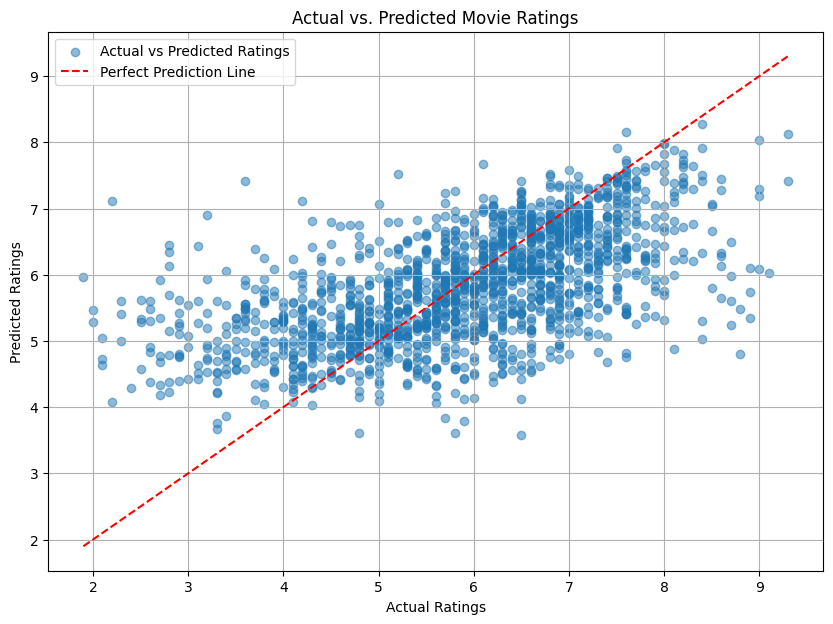

In [12]:
import matplotlib.pyplot as plt

# Create a scatter plot
plt.figure(figsize=(10, 7))
plt.scatter(y_test, y_pred, alpha=0.5, label='Actual vs Predicted Ratings')

# Add a line for perfect predictions (y=x)
# Determine the range for the line based on min/max of actual and predicted ratings
min_rating = min(y_test.min(), y_pred.min())
max_rating = max(y_test.max(), y_pred.max())
plt.plot([min_rating, max_rating], [min_rating, max_rating], 'r--', label='Perfect Prediction Line')

# Set labels and title
plt.xlabel('Actual Ratings')
plt.ylabel('Predicted Ratings')
plt.title('Actual vs. Predicted Movie Ratings')

# Add legend and grid
plt.legend()
plt.grid(True)
plt.show()

## Final Task

### Subtask:
Summarize the movie rating prediction project, including the models used, performance metrics, and any key insights or observations from the visualization.


## Summary:

### Data Analysis Key Findings

*   **Data Loading and Initial State**: The `IMDb Movies India.csv` dataset was successfully loaded, containing 15,509 entries and 10 columns. Initial inspection revealed numerous missing values across several columns, including 'Year', 'Duration', 'Genre', 'Rating', 'Votes', 'Director', and actor columns.
*   **Missing Ratings Handling**: Rows with missing 'Rating' values were removed, reducing the dataset from 15,509 to 7,919 entries.
*   **Data Cleaning - 'Year' Column**: The 'Year' column was cleaned by removing parentheses and converting its data type from `object` to `int64`.
*   **Data Cleaning - 'Duration' Column**: The 'Duration' column was cleaned by removing the ' min' suffix and converting its data type from `object` to a nullable integer (`Int64`), preserving `NaN` values.
*   **Data Cleaning - 'Votes' Column**: The 'Votes' column was cleaned by removing commas and converting its data type from `object` to a nullable integer (`Int64`).
*   **Feature Engineering**:
    *   'Genre', 'Director', and 'Actor 1' columns were selected for feature engineering.
    *   Missing values in these columns were filled with the string 'Missing'.
    *   Frequency Encoding was applied to these columns, converting them from `object` type to `int64` based on the frequency of each unique value.
*   **Data Splitting**: The preprocessed data was split into training and testing sets with an 80/20 ratio. The training set (X\_train, y\_train) contains 6,335 samples, and the testing set (X\_test, y\_test) contains 1,584 samples.
*   **Model Training**: A `RandomForestRegressor` model was successfully trained on the preprocessed training data.
*   **Model Evaluation**: The trained `RandomForestRegressor` model achieved a Mean Squared Error (MSE) of 1.2237 and an R-squared (R2) score of 0.3418 on the test set.
*   **Visualization**: A scatter plot comparing actual versus predicted ratings illustrated the model's performance, showing the spread of predictions against the ideal perfect prediction line.

### Insights or Next Steps

*   The model's R-squared score of approximately 0.34 suggests that while it captures some variance in movie ratings, a significant portion remains unexplained. Further feature engineering or exploring more complex models could improve performance.
*   Investigate the residuals from the model to understand where predictions are weakest, and consider incorporating additional features such as movie budgets, box office performance, or sentiment analysis of reviews to enhance predictive power.
